# Week 3 Lab - Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, f1_score
)

# Load and Replace -999 values with NA
df_raw = pd.read_csv('data/EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


# 1. Create target variable & explore

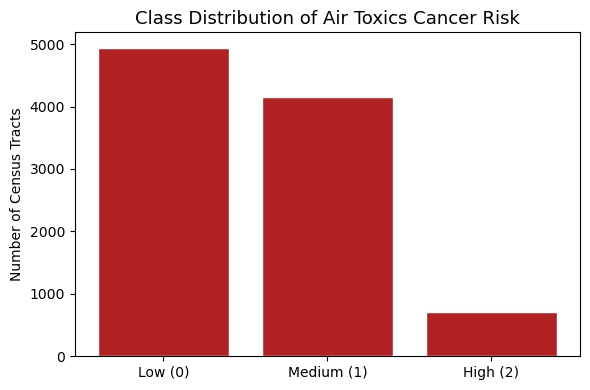


Class counts:
 risk_class
Low       4942
Medium    4148
High       702
Name: count, dtype: int64


In [4]:
def make_risk_class(epl):
    if pd.isna(epl):
        return np.nan
    elif epl < 0.33:
        return 0
    elif epl < 0.67:
        return 1
    else:
        return 2

df['risk_class'] = df['EPL_TOTCR'].apply(make_risk_class)

counts = df['risk_class'].value_counts().sort_index()
labels = ['Low (0)', 'Medium (1)', 'High (2)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color="firebrick", edgecolor='white')
ax.set_title('Class Distribution of Air Toxics Cancer Risk', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()
print('\nClass counts:\n', counts.rename({0: 'Low', 1: 'Medium', 2: 'High'}))

## 1b. Check variable scales

In [5]:
FEATURES = ['E_DSLPM', 'E_PM', 'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_POV200', 'E_MINRTY']

for f in FEATURES:
    lo  = df[f].min()
    hi  = df[f].max()
    rng = hi - lo
    print(f"{f:<14}  {lo:>10.4f}  {hi:>10.4f}  {rng:>10.4f}")

E_DSLPM             0.0069      1.7343      1.7274
E_PM                0.0000      9.5750      9.5750
E_NPL               0.0000    100.0000    100.0000
E_TRI               0.0000    100.0000    100.0000
E_TSD               0.0000    100.0000    100.0000
E_RMP               0.0000    100.0000    100.0000
E_POV200            0.0000    100.0000    100.0000
E_MINRTY            0.0000    100.0000    100.0000


# 2. Prepare features & apply scale

In [ ]:
from pandas._typing import RandomState
var_of_interest = ['E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_DSLPM', 'E_PM', 'E_POV200', 'E_MINRTY', 'risk_class']

df_model = df[var_of_interest].dropna()
X = df_model[['E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_DSLPM', 'E_PM', 'E_POV200', 'E_MINRTY']]
y = df_model['risk_class'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, stratify=y, random_state=42)

# scale on X training data, transform features
scaler    = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train) # scale x
X_test_s  = scaler.transform(X_test) # scale x

print(f'Training set : {X_train_s.shape[0]:,} tracts')
print(f'Test set     : {X_test_s.shape[0]:,} tracts')

Training set : 6,815 tracts
Test set     : 2,921 tracts


# 3. Run KNN (k=3)

In [20]:
knn3 = KNeighborsClassifier(n_neighbors=3) # initiliaze model
knn3.fit(X_train_s, y_train) # train/fit model
y_pred = knn3.predict(X_test_s) # predict on test set

knn3_accuracy = accuracy_score(y_test, y_pred)
print(f'KNN (k=3) accuracy: {knn3_accuracy:.4f}')

KNN (k=3) accuracy: 0.6039


# 4. Confusion matrix

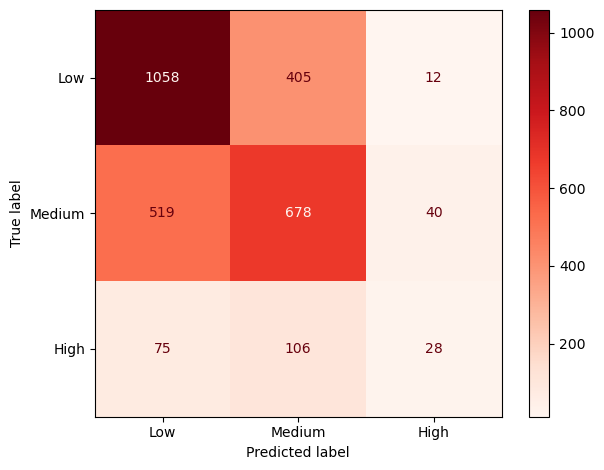

In [17]:
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots()
cm_display.plot(ax=ax, cmap='Reds')
plt.tight_layout()

# 5. Calculate accuracy metrics

In [24]:
# ── Accuracy ──────────────────────────────────────────────────────────────────
correct = np.trace(cm)
total   = cm.sum()
accuracy_manual = correct / total

print(f"Accuracy = {correct} / {total} = {accuracy_manual:.4f}")

# ── Low (class 0) ─────────────────────────────────────────────────────────────
TP_low = cm[0, 0]
FP_low = cm[1, 0] + cm[2, 0]   # Medium and High predicted as Low
FN_low = cm[0, 1] + cm[0, 2]   # Low predicted as Medium or High

precision_low = TP_low / (TP_low + FP_low)
recall_low    = TP_low / (TP_low + FN_low)
f1_low        = 2 * precision_low * recall_low / (precision_low + recall_low)

print(f"Low    — TP: {TP_low}  FP: {FP_low}  FN: {FN_low}")
print(f"         Precision: {precision_low:.4f}  Recall: {recall_low:.4f}  F1: {f1_low:.4f}\n")

# ── Medium (class 1) ──────────────────────────────────────────────────────────
TP_med = cm[1, 1]
FP_med = cm[0, 1] + cm[2, 1]   # Low and High predicted as Medium
FN_med = cm[1, 0] + cm[1, 2]   # Medium predicted as Low or High

precision_med = TP_med / (TP_med + FP_med)
recall_med    = TP_med / (TP_med + FN_med)
f1_med        = 2 * precision_med * recall_med / (precision_med + recall_med)

print(f"Medium — TP: {TP_med}  FP: {FP_med}  FN: {FN_med}")
print(f"         Precision: {precision_med:.4f}  Recall: {recall_med:.4f}  F1: {f1_med:.4f}\n")

# ── High (class 2) ────────────────────────────────────────────────────────────
TP_high = cm[2, 2]
FP_high = cm[0, 2] + cm[1, 2]  # Low and Medium predicted as High
FN_high = cm[2, 0] + cm[2, 1]  # High predicted as Low or Medium

precision_high = TP_high / (TP_high + FP_high)
recall_high    = TP_high / (TP_high + FN_high)
f1_high        = 2 * precision_high * recall_high / (precision_high + recall_high)

print(f"High   — TP: {TP_high}  FP: {FP_high}  FN: {FN_high}")
print(f"         Precision: {precision_high:.4f}  Recall: {recall_high:.4f}  F1: {f1_high:.4f}")

# ── Macro average ─────────────────────────────────────────────────────────────
macro_precision = (precision_low + precision_med + precision_high) / 3
macro_recall    = (recall_low    + recall_med    + recall_high)    / 3
macro_f1        = (f1_low        + f1_med        + f1_high)        / 3

print(f"Macro avg — Precision: {macro_precision:.4f}  Recall: {macro_recall:.4f}  F1: {macro_f1:.4f}")

Accuracy = 1764 / 2921 = 0.6039
Low    — TP: 1058  FP: 594  FN: 417
         Precision: 0.6404  Recall: 0.7173  F1: 0.6767

Medium — TP: 678  FP: 511  FN: 559
         Precision: 0.5702  Recall: 0.5481  F1: 0.5589

High   — TP: 28  FP: 52  FN: 181
         Precision: 0.3500  Recall: 0.1340  F1: 0.1938
Macro avg — Precision: 0.5202  Recall: 0.4665  F1: 0.4765


In [ ]:
sk_accuracy = accuracy_score(y_test, y_pred)

# macro-averaged metrics
sk_precision = precision_score(y_test, y_pred, average='macro')
sk_recall = recall_score(y_test, y_pred, average='macro')
sk_f1 = f1_score(y_test, y_pred, average='macro')

print("=== Sklearn Built-in (Macro) Metrics ===")
print(f"Accuracy          : {sk_accuracy:.4f}")
print()
print(f"Macro Precision   : {sk_precision:.4f}")
print(f"Macro Recall      : {sk_recall:.4f}")
print(f"Macro F1          : {sk_f1:.4f}")

=== Sklearn Built-in (Macro) Metrics ===
Accuracy          : 0.6039

Macro Precision   : 0.5202
Macro Recall      : 0.4665
Macro F1          : 0.4765
